<center>

## <font color='maroon'>Classifying light curves with convolutional neural networks</font>

<p>



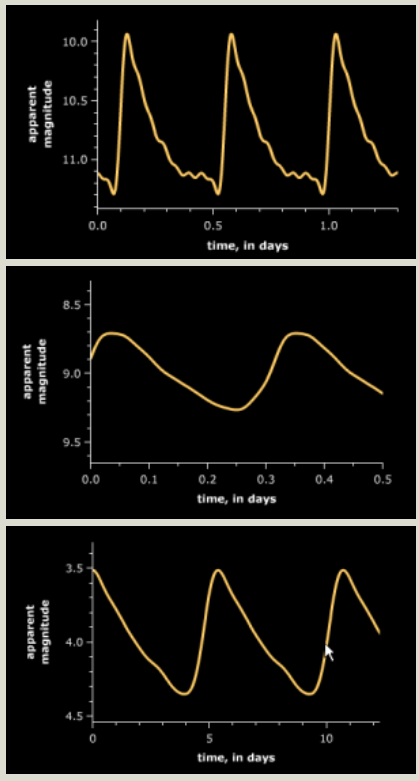

### Background

Many astronomical objects emit flux that varies with time. When variations of measured flux (often expressed as a magnitude) are plotted over time, the resulting graph is called a light curve.

Stars, in particular, vary for a variety of reasons. Although all stars (including our Sun!) vary by a small amount, some stars vary a lot. The shape and form of the star's light curve can be used to understand what type of star we are observing and glean information about physical conditions within the star. 

However, classifying light curves in general presents challenges. Most light curves are irregularly sampled as a function of time, and often have gaps in coverage. Unfortunately, standard statistical methods that can be applied to well-sampled light curves may not work at all for sparsely sampled ones. Additionally, while it is easy to create a high-quality training sample of labeled light curves, there are many more light curves that are ambiguous and cannot confidently be labeled. This means that feature-based machine learning classifiers such as RandomForest are not able to perform well on large light curve datasets except under ideal data conditions.

In this project I use a sample of variable star light curves from the [OGLE experiment](https://ogle.astrouw.edu.pl/), which has been operating for a couple of decades and is designed to detect variable stars. The experiment produced a large sample of variable stars of different types. These light curves cover different timespans, and gaps in coverage are frequent. In this project, I devise an algorithm that can classify these light curves with a high degree of confidence despite these challenges. 

More specifically, I will develop a classification scheme using a Convolutional Neural Network (CNN) method. The CNN method is known to produce excellent results in classifying objects in images. In this project I utilise a novel approach by [Mahabal+2017](https://arxiv.org/pdf/1709.06257.pdf) for converting light curves into images for classification with a CNN, which avoids some of the issues with classification mentioned above.


**Background reading**

* [Mahabal+2017](https://arxiv.org/pdf/1709.06257.pdf).

* How light curves of different types of variable stars look in the OGLE database [here](http://ogle.astrouw.edu.pl/atlas/). An overview of variable stars and their light curves can be found in this [PDF file](https://www.aavso.org/sites/default/files//Variable%20Star%20Classification%20and%20Light%20Curves%20Manual%202.1.pdf).


In [158]:
import tensorflow
from tensorflow import keras

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from keras import layers
import keras_tuner as kt
import pickle


### Some preliminaries

In [ ]:
path_to_data = '/Users/charlesmarsden/Documents/UChicago Work/ASTR 211/Machine Learning/Light curve classification/proj_light_curves_data'

In [ ]:
# Defines lists containing the IDs of different variable types in the database
cepheid = list(range(1,5001))
ecl = list(range(5001,10001))
rrly = list(range(10001,15001))
ds = list(range(15001,20001))
lpv = list(range(20001,25001))

# Defines a list containing the IDs of all stars in the database
all_stars = list(range(1, 25001))

In [6]:
import os
import numpy as np

def glc(lc_id, return_extras=False, path_to_data=None):
    '''
    Gets the data for a given light curve. glc = "Get Light Curve"
    
    Parameters
    ----------
    lc_id : integer
        Light curve ID in the range [1,50000]

    return_extras: Boolean : default=False
        If True, the function will return all 3 items under "Returns"
        If False, the function will only return the light curve (lc)
        
    Returns
    -------
    lc : Numpy array with shape (3, len(lc))
        The light curve. lc[0] gives the time values, lc[1] gives the 
        magnitudes, and lc[2] gives the magnitude errors.
        
    lc_type : str
        The type of the light curve. Can be 'cepheid', 'ecl', 'rrly', 
        'ds' or 'lpv.' Returned only if return_extras is True.
        
    OGLE_id : str
        The OGLE ID of the light curve. Can be used to look up a star
        in the OGLE database. Returned only if return_extras is True.
    
    '''
    if path_to_data is None:
        print('Set path_to_data before using gcl!')
        
    lc = np.load(os.path.join(path_to_data, 'curves', str(lc_id) + '.npy'))
    with open(os.path.join(path_to_data, 'info.txt')) as file:
        lc_data = [line for line in file if line.startswith(str(lc_id))][0].split()
    lc_type, OGLE_id = lc_data[1:]
    if return_extras: return lc, lc_type, OGLE_id 
    return lc

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns # to plot the confusion matrix prettier

def conf_matrix(y_test, y_pred, class_names=None):
    """
    helper function computing confusion matrix
    """
    conf_mat = confusion_matrix(y_test, y_pred).T
    conf_mat = conf_mat.astype(float)

    # normalize confusion fraction
    for i in range(len(class_names)):
        conf_mat[i,:] /= float(np.sum(conf_mat[i,:]))

    return conf_mat

def plot_confusion_matrix(y_test, ypred, class_names = None,
                          title=None, figsize=(3,3)):
    conf_mat = conf_matrix(y_test, ypred, class_names=class_names)

    plt.figure(figsize = figsize)
    if title is not None:
        plt.title(title, fontsize=10)
    sns.heatmap(conf_mat.T, square = True, annot=True, fmt='.3f', cmap='Blues', cbar=False,
               xticklabels= class_names,
               yticklabels= class_names)

    plt.xlabel('true label')
    plt.ylabel('predicted label')
    plt.show()

### Function that takes in a light curve and returns a 2D array representing the dm-dt image of that light curve

In [9]:
# lc_data = {}

# for lc_id in all_stars:
#     lc = glc(lc_id, return_extras=False, path_to_data=path_to_data)
#     times, magnitudes, magnitude_errors = lc[0], lc[1], lc[2]
#     lc_data[lc_id] = {"times": times,
#                       "magnitudes": magnitudes,
#                       "magnitude_errors": magnitude_errors}

In [10]:
# with open('/Users/charlesmarsden/Documents/UChicago Work/ASTR 211/Machine Learning/Light curve classification/lc_data.pkl', 'wb') as f:
    # pickle.dump(lc_data, f, protocol=pickle.HIGHEST_PROTOCOL)

with open('/Users/charlesmarsden/Documents/UChicago Work/ASTR 211/Machine Learning/Light curve classification/lc_data.pkl', 'rb') as f:
    lc_data = pickle.load(f)

In [ ]:
# original bins
# dt_bins_mahabal =[1/145, 2/145, 3/145, 4/145, 1/25, 2/25, 3/25, 1.5, 2.5, 3.5, 4.5, 5.5, 7, 10,20,30,60,90,120,240,600,960,2000,4000] # days
# dm_bins_mahabal = [-8, -5, -3, -2.5, -2, -1.5, -1, -0.5, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.5, 1, 1.5, 2, 2.5, 3, 5, 8] # mags

# adjusted
dt_bins_broad =[1/145, 2/145, 3/145, 4/145, 1/25, 2/25, 3/25, 1.5, 2.5, 3.5, 4.5, 5.5, 7, 10,20,30,60,90,120,240,360,600,960,1540,2000,4000] # days
dm_bins_broad = [-8, -5, -3, -2.5, -2, -1.5, -1, -0.5, -0.3, -0.2, -0.1, -0.05, -0.02, 0, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 1, 1.5, 2, 2.5, 3, 5, 8] # mags

# numer of elements in each of these arrays must be equal for subsequent parts of the code to work

# # RRLY
# dt_bins_rrly =[1/5, 1/2, 1, 1.5, 2.5, 3.5, 4.5, 5.5, 7, 10,20,30,60,90,120,240] # days
# dm_bins_rrly = [-1, -0.75, -0.5, -0.4, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1] # mags

# # DS
# dt_bins_ds =[1/5, 1/2, 1, 1.5, 2.5, 3.5, 4.5, 5.5, 7, 10,20,30,60,90,120,240] # days
# dm_bins_ds = [-0.5, -0.4, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5] # mags


dt_bins_cepheid = dt_bins_broad
dm_bins_cepheid = dm_bins_broad
dm_bins_ecl = dm_bins_broad
dt_bins_ecl = dt_bins_broad

dt_bins_rrly = dt_bins_broad
dm_bins_rrly = dm_bins_broad
dt_bins_ds = dt_bins_broad
dm_bins_ds = dm_bins_broad

dt_bins_lpv = dt_bins_broad
dm_bins_lpv = dm_bins_broad

In [12]:
def create_dm_dt(lc_id, dt_bins, dm_bins):

    times, magnitudes = np.asarray(lc_data[lc_id]['times']), np.asarray(lc_data[lc_id]['magnitudes'])

    dts_all = times[:,None] - times[None,:] # matrix where (i,j) is time[i] - time[j]
    dms_all = magnitudes[:,None] - magnitudes[None,:]
    
    positive_times = dts_all > 0
    dts = dts_all[positive_times]
    dms = dms_all[positive_times]

    hist, _, _ = np.histogram2d(dts, dms, bins=[dt_bins, dm_bins]) # hist is rows (dts) then columns (dms)

    pixel_values = hist.T # array
    n_points = len(dts)

    dmdt_img = (255*pixel_values/n_points + 0.99999).astype(int)

    return dmdt_img

In [ ]:
# Create a dictionary containing the dmdt arrays of every object (indexed from 1; id1 ~ dmdt_arrays[1])

# dmdt_arrays = {}

# for lc_id in all_stars:
    
#     if lc_id <= 5000:
#         dmdt_arrays[lc_id] = create_dm_dt(lc_id, dt_bins_cepheid, dm_bins_cepheid)
#     elif lc_id <= 10000:
#         dmdt_arrays[lc_id] = create_dm_dt(lc_id, dt_bins_ecl, dm_bins_ecl)
#     elif lc_id <= 15000:
#         dmdt_arrays[lc_id] = create_dm_dt(lc_id, dt_bins_rrly, dm_bins_rrly)
#     elif lc_id <= 20000:
#         dmdt_arrays[lc_id] = create_dm_dt(lc_id, dt_bins_ds, dm_bins_ds)
#     elif lc_id <= 25000:
#         dmdt_arrays[lc_id] = create_dm_dt(lc_id, dt_bins_lpv, dm_bins_lpv)

#     else:
#         print(f"ERROR: no object with id={lc_id}")

In [ ]:
# with open('/Users/charlesmarsden/Documents/UChicago Work/ASTR 211/Machine Learning/Light curve classification/dmdt_arrays.pkl', 'wb') as f:
#     pickle.dump(dmdt_arrays, f, protocol=pickle.HIGHEST_PROTOCOL)

with open('/Users/charlesmarsden/Documents/UChicago Work/ASTR 211/Machine Learning/Light curve classification/dmdt_arrays.pkl', 'rb') as f:
    dmdt_arrays = pickle.load(f)

In [ ]:
# # Create array of labels (indexed from 0; id1 ~ labels[0])

# all_stars2 = list(range(1, 25001))

# labels = np.empty_like(all_stars2)

# labels[0:5000] = 0 # cepheid
# labels[5000:10000] = 1 # ecl
# labels[10000:15000] = 2 # rrly
# labels[15000:20000] = 3 # ds
# labels[20000:25000] = 4 # lpv

In [14]:

# with open('/Users/charlesmarsden/Documents/UChicago Work/ASTR 211/Machine Learning/Light curve classification/labels.pkl', 'wb') as f:
#     pickle.dump(labels, f, protocol=pickle.HIGHEST_PROTOCOL)

with open('/Users/charlesmarsden/Documents/UChicago Work/ASTR 211/Machine Learning/Light curve classification/labels.pkl', 'rb') as f:
    labels = pickle.load(f)

### Function that takes in one or more dm-dt images and produces a visualization of the image(s). Stacking multiple dm-dt images for objects in the same class creates composite image like those shown in [Mahabal+2017](https://arxiv.org/pdf/1709.06257.pdf)

In [15]:
def visualise_dmdt(img, dt_bins, dm_bins, title=""):
    fig, ax = plt.subplots()
    im = ax.imshow(img, origin="lower", cmap="viridis", aspect="equal")
    fig.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("dt (days)")
    ax.set_ylabel("dm (mags)")

    x_idx = list(range(0, len(dt_bins), 3))
    ax.set_xticks([k - 0.5 for k in x_idx]) # pixels are in the middle of edges
    ax.set_xticklabels([f"{dt_bins[k]:.1g}" if dt_bins[k] <= 1 else str(dt_bins[k]) for k in x_idx])

    y_idx = list(range(0, len(dm_bins), 2))
    ax.set_yticks([k - 0.5 for k in y_idx])
    ax.set_yticklabels([str(dm_bins[k]) for k in y_idx])

    plt.show()

In [16]:
# RUN dmdt_arrays DICTIONARY BUILD BEFORE RUNNING THIS CELL

cepheids = list(range(1,5001))
ecl = list(range(5001,10001))
rrly = list(range(10001,15001))
ds = list(range(15001,20001))
lpv = list(range(20001,25001))


def visualise_cepheids(cepheids = list(range(1,5001))):
    cepheid_array_template = dmdt_arrays[1]
    dmdt_cepheid = np.zeros_like(cepheid_array_template).astype('float32')
    for cepheid_id in cepheids:
        dmdt_array = dmdt_arrays[cepheid_id]
        dmdt_cepheid += dmdt_array
    dmdt_cepheid /= len(cepheids)
    visualise_dmdt(dmdt_cepheid, dm_bins=dm_bins_cepheid, dt_bins=dt_bins_cepheid, title="Cepheid")

def visualise_ecl(ecl = list(range(5001,10001))):
    ecl_array_template = dmdt_arrays[5001]
    dmdt_ecl = np.zeros_like(ecl_array_template).astype('float32')
    for ecl_id in ecl:
        dmdt_array = dmdt_arrays[ecl_id]
        dmdt_ecl += dmdt_array
    dmdt_ecl /= len(ecl)
    visualise_dmdt(dmdt_ecl, dm_bins=dm_bins_ecl, dt_bins=dt_bins_ecl, title="ECL")

def visualise_rrly(rrly = list(range(10001,15001))):
    rrly_array_template = dmdt_arrays[10001]
    dmdt_rrly = np.zeros_like(rrly_array_template).astype('float32')
    for rrly_id in rrly:
        dmdt_array = dmdt_arrays[rrly_id]
        dmdt_rrly += dmdt_array
    dmdt_rrly /= len(rrly)
    visualise_dmdt(dmdt_rrly, dm_bins=dm_bins_rrly, dt_bins=dt_bins_rrly, title="RRLY")

def visualise_ds(ds = list(range(15001,20001))):
    ds_array_template = dmdt_arrays[15001]
    dmdt_ds = np.zeros_like(ds_array_template).astype('float32')
    for ds_id in ds:
        dmdt_array = dmdt_arrays[ds_id]
        dmdt_ds += dmdt_array
    dmdt_ds /= len(ds)
    visualise_dmdt(dmdt_ds, dm_bins=dm_bins_ds, dt_bins=dt_bins_ds, title="DS")

def visualise_lpv(lpv = list(range(20001,25001))):
    lpv_array_template = dmdt_arrays[20001]
    dmdt_lpv = np.zeros_like(lpv_array_template).astype('float32')
    for lpv_id in lpv:
        dmdt_array = dmdt_arrays[lpv_id]
        dmdt_lpv += dmdt_array
    dmdt_lpv /= len(lpv)
    visualise_dmdt(dmdt_lpv, dm_bins=dm_bins_cepheid, dt_bins=dt_bins_cepheid, title="LPV")

### DMDT Images

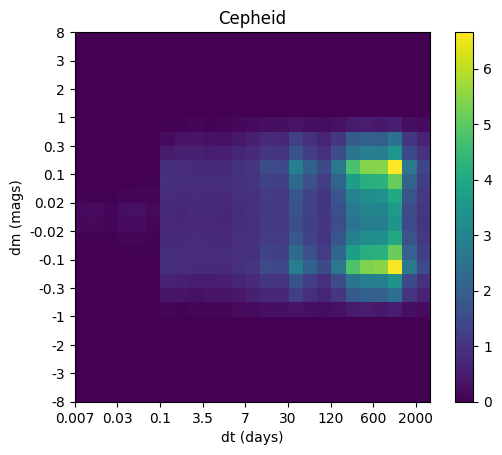

In [17]:
visualise_cepheids()

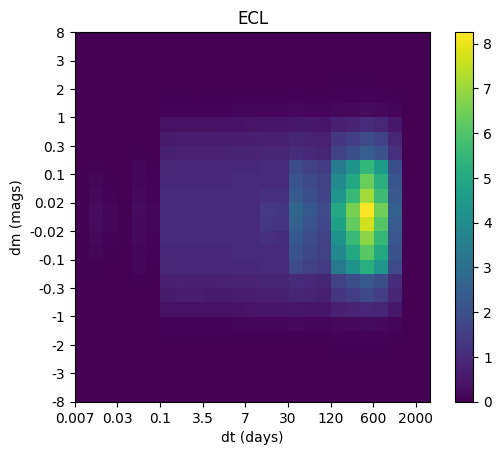

In [18]:
visualise_ecl()

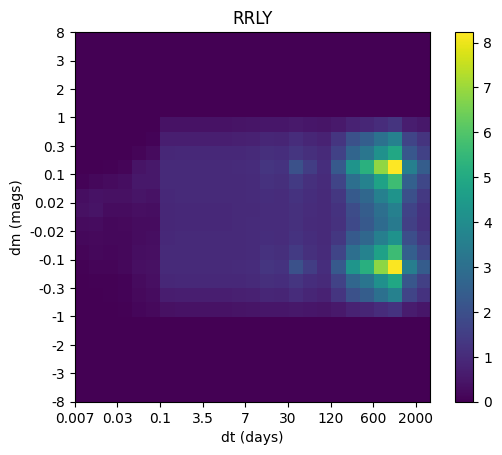

In [19]:
visualise_rrly()

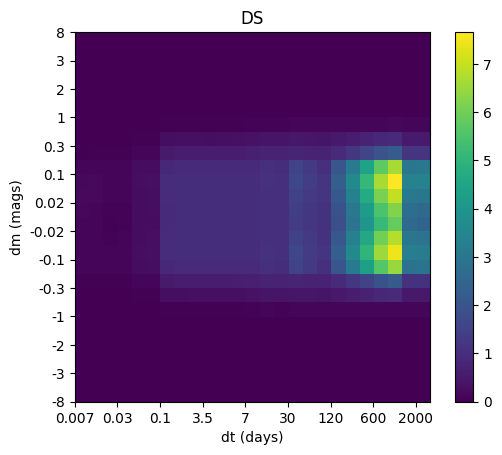

In [20]:
visualise_ds()

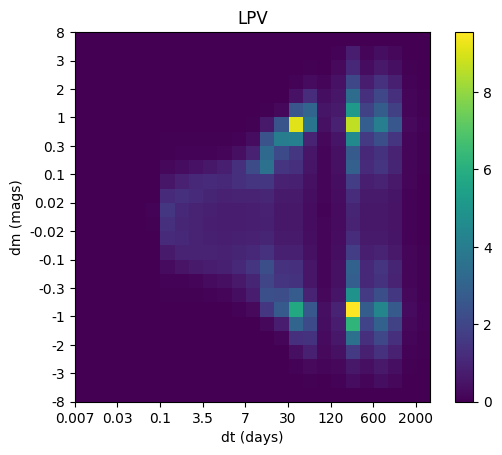

In [21]:
visualise_lpv()

### Prepare data for tensorflow cnn


In [17]:
N = len(all_stars)
W = len(dt_bins_broad) - 1
H = len(dm_bins_broad) - 1

cube = np.empty((N, H, W)).astype('float32')

for k, lc_id in enumerate(all_stars):
    cube[k] = dmdt_arrays[lc_id]

In [18]:
cube.shape

(25000, 26, 25)

In [19]:
# transform cube into 4d tensor
# Conv2D layer expects inputs to have a dimension specifying the number of channels for the data (e.g. 1 for grayscale, 3 for RGB)
cube = cube[...,None] # (25000,26,24) -> (25000,26,24,1)

# split cube into training images (80%) and test/validation images (20%)
X_train, X_test_validate, Y_train, Y_test_validate = train_test_split(cube, labels, train_size = 0.8, stratify=labels, random_state=42)

# of the 20% of the data set, testing and validation data make up 10% each
X_test, X_validate, Y_test, Y_validate = train_test_split(X_test_validate, Y_test_validate, train_size=0.5, stratify=Y_test_validate, random_state=42)

In [20]:
X_train.shape[1:]

(26, 25, 1)


Please note: Once you have figured out how to make dm-dt images, it is best to do steps 3 and 4 only once, and save the output to a file that can be loaded in each time you open your notebook again. Recreating the images each time will be a very slow and very intensive process for your computer. Please reach out if you need help with saving the images to a file!

# CNN Classifier

[Mahabal+2017](https://arxiv.org/pdf/1709.06257.pdf) shallow architecture


In [200]:
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', name='images')(inputs)
    x = layers.Dropout(rate=0.1, name='dropout_1')(x)

    x = layers.Flatten()(x)

    x = layers.Dense(units=128, name='dense_1')(x)
    x = layers.Dropout(rate=0.25, name='dropout_2')(x)
    x = layers.Dense(units=128, name='dense_2')(x)

    outputs = layers.Dense(units=num_classes, activation='softmax', name='predictions')(x)

    return keras.Model(inputs,outputs)

In [206]:
model = make_model(input_shape=X_train.shape[1:], num_classes=5)
# keras.utils.plot_model(model,show_shapes=True)

In [207]:
model.compile(optimizer=keras.optimizers.Adam(0.0004832930238571752),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.SparseCategoricalAccuracy()])

In [208]:
print("Fit model on training data")
history = model.fit(X_train,Y_train,
                    batch_size=64,
                    epochs=6,
                    validation_data=(X_validate,Y_validate))

Fit model on training data
Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.2784 - sparse_categorical_accuracy: 0.9123 - val_loss: 0.1550 - val_sparse_categorical_accuracy: 0.9468
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.1378 - sparse_categorical_accuracy: 0.9551 - val_loss: 0.1295 - val_sparse_categorical_accuracy: 0.9568
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.1108 - sparse_categorical_accuracy: 0.9632 - val_loss: 0.1219 - val_sparse_categorical_accuracy: 0.9564
Epoch 4/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0926 - sparse_categorical_accuracy: 0.9687 - val_loss: 0.1037 - val_sparse_categorical_accuracy: 0.9648
Epoch 5/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0815 - sparse_categorical_accuracy: 0.9714 - val_loss: 0.1091 - val_sparse_categorical_accuracy: 0.9648
Epoch 6/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0800 - sparse_categorical_accuracy: 0.9725 - val_loss: 0.0943 - val_sparse_catego

In [210]:
results = model.evaluate(X_test,Y_test,batch_size=128)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1002 - sparse_categorical_accuracy: 0.9704


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


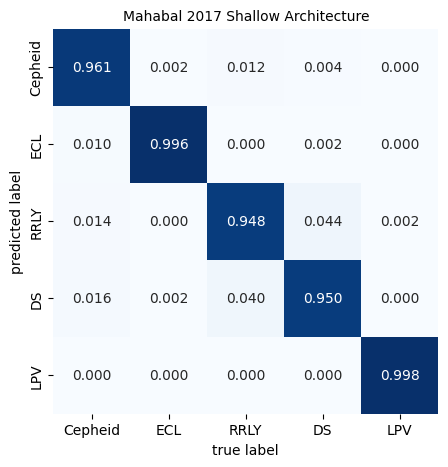

In [211]:
Y_pred_probs = model.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)
plot_confusion_matrix(Y_test, Y_pred, title=f'Mahabal 2017 Shallow Architecture', class_names=['Cepheid','ECL','RRLY','DS','LPV'], figsize=(5,5))

**Mahabal shallow model hyperparameter optimisation with keras_tuner; attempting to find the optimal learning rate**

In [168]:
def make_shallow_model(hp, input_shape=X_train.shape[1:], num_classes=5):
    shallow_model = keras.Sequential()

    shallow_model.add(keras.Input(shape=input_shape))

    shallow_model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', name='images'))
    shallow_model.add(layers.Dropout(rate=0.1, name='dropout_1'))

    shallow_model.add(layers.Flatten())

    shallow_model.add(layers.Dense(units=128, name='dense_1'))
    shallow_model.add(layers.Dropout(rate=0.25, name='dropout_2'))
    shallow_model.add(layers.Dense(units=128, name='dense_2'))

    shallow_model.add(layers.Dense(units=num_classes, activation='softmax', name='predictions'))

    options = list(np.logspace(-5,-1, num=20, base=10))
    hp_learning_rate = hp.Choice('learning_rate', values=options)

    shallow_model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.SparseCategoricalAccuracy()])
    
    return shallow_model

In [169]:
shallow_model_tuner = kt.Hyperband(make_shallow_model,
                                   objective='val_loss',
                                   max_epochs=50,
                                   factor=3,
                                   seed=42,)

In [170]:
shallow_model_tuner.search(X_train,Y_train, epochs=50, validation_data=(X_validate,Y_validate))

Trial 20 Complete [00h 00m 17s]
val_loss: 0.1440090537071228

Best val_loss So Far: 0.11500243842601776
Total elapsed time: 00h 05m 32s


In [171]:
best_hps=shallow_model_tuner.get_best_hyperparameters(num_trials=1)[0] # list with the best 1 config

In [ ]:
print('Best learning rate:', best_hps.get('learning_rate'))

0.0004832930238571752

In [176]:
shallow_model = shallow_model_tuner.hypermodel.build(best_hps)

history = shallow_model.fit(X_train,Y_train,
                    batch_size=64,
                    epochs=50,
                    validation_data=(X_validate,Y_validate))

val_acc_per_epoch = history.history['val_sparse_categorical_accuracy']
best_epoch = val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
print('Best epoch: %d' % (best_epoch,))

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.2793 - sparse_categorical_accuracy: 0.9093 - val_loss: 0.1801 - val_sparse_categorical_accuracy: 0.9352
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1381 - sparse_categorical_accuracy: 0.9550 - val_loss: 0.1315 - val_sparse_categorical_accuracy: 0.9576
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1109 - sparse_categorical_accuracy: 0.9632 - val_loss: 0.1320 - val_sparse_categorical_accuracy: 0.9564
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0980 - sparse_categorical_accuracy: 0.9672 - val_loss: 0.1133 - val_sparse_categorical_accuracy: 0.9636
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0859 - sparse_categorical_accuracy: 0.9712 - val_loss: 0.1126 - val_sparse_categorical_accuracy: 0.9636
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0825 - sparse_categorical_accuracy: 0.9726 - val_loss: 0.1174 - val_sparse_categorical_accuracy: 0.961

In [192]:
shallow_hypermodel = shallow_model_tuner.hypermodel.build(best_hps)

shallow_hypermodel.fit(X_train, Y_train, epochs=best_epoch, validation_data=(X_validate,Y_validate))

Epoch 1/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.2784 - sparse_categorical_accuracy: 0.9114 - val_loss: 0.1427 - val_sparse_categorical_accuracy: 0.9548
Epoch 2/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.1357 - sparse_categorical_accuracy: 0.9540 - val_loss: 0.1382 - val_sparse_categorical_accuracy: 0.9572
Epoch 3/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.1109 - sparse_categorical_accuracy: 0.9627 - val_loss: 0.1351 - val_sparse_categorical_accuracy: 0.9564
Epoch 4/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0969 - sparse_categorical_accuracy: 0.9668 - val_loss: 0.1032 - val_sparse_categorical_accuracy: 0.9640
Epoch 5/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0899 - sparse_categorical_accuracy: 0.9696 - val_loss: 0.1307 - val_sparse_categorical_accuracy: 0.9568
Epoch 6/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0814 - sparse_categorical_accuracy: 0.9732 - val_loss: 0.1222 - val_sparse_categorical_accuracy: 0.9664
Epoc

In [193]:
results = shallow_hypermodel.evaluate(X_test,Y_test,batch_size=128)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1414 - sparse_categorical_accuracy: 0.9656


# Exploring deeper architectures

Mahabal 2017 deep architecture

In [186]:
def make_model_mahabal_deep(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu')(inputs)
    x = layers.MaxPool2D(pool_size=(2,2))(x)
    x = layers.Dropout(rate=0.1)(x)

    x = layers.Conv2D(filters=128, kernel_size=(5,5), activation='relu')(x)
    x = layers.Conv2D(filters=256, kernel_size=(5,5), activation='relu')(x)

    x = layers.Flatten()(x)

    x = layers.Dense(units=512)(x)
    x = layers.Dropout(rate=0.5)(x)
    x = layers.Dense(units=512)(x)

    outputs = layers.Dense(units=num_classes, activation='softmax')(x)

    return keras.Model(inputs,outputs)

In [187]:
model_mahabal_deep = make_model_mahabal_deep(input_shape=X_train.shape[1:], num_classes=5)

In [188]:
# keras.utils.plot_model(model_mahabal_deep,show_shapes=True)

In [189]:
model_mahabal_deep.compile(optimizer=keras.optimizers.Adam(0.0004832930238571752),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.SparseCategoricalAccuracy()])

In [190]:
history = model_mahabal_deep.fit(X_train,Y_train,
                    batch_size=64,
                    epochs=9,
                    validation_data=(X_validate,Y_validate))

Epoch 1/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.2775 - sparse_categorical_accuracy: 0.8986 - val_loss: 0.2291 - val_sparse_categorical_accuracy: 0.9204
Epoch 2/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.1259 - sparse_categorical_accuracy: 0.9580 - val_loss: 0.1172 - val_sparse_categorical_accuracy: 0.9600
Epoch 3/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0985 - sparse_categorical_accuracy: 0.9666 - val_loss: 0.1115 - val_sparse_categorical_accuracy: 0.9604
Epoch 4/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0850 - sparse_categorical_accuracy: 0.9703 - val_loss: 0.1019 - val_sparse_categorical_accuracy: 0.9664
Epoch 5/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0787 - sparse_categorical_accuracy: 0.9719 - val_loss: 0.0925 - val_sparse_categorical_accuracy: 0.9676
Epoch 6/9
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0639 - sparse_categorical_accuracy: 0.9772 - val_loss: 0.1020 - val_sparse_categorical_accuracy: 0.9692
Epoc

In [191]:
results = model_mahabal_deep.evaluate(X_test,Y_test,batch_size=128)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0921 - sparse_categorical_accuracy: 0.9712


79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


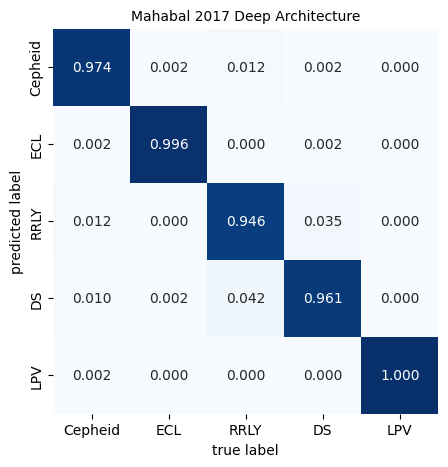

In [125]:
Y_pred_probs = model_mahabal_deep.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)
plot_confusion_matrix(Y_test, Y_pred, title=f'Mahabal 2017 Deep Architecture', class_names=['Cepheid','ECL','RRLY','DS','LPV'], figsize=(5,5))

In [39]:
def make_model_test1(input_shape, num_classes):
    # essentially the mahabal deep architecture with some more layers, mostly dense and dropout, added somewhat arbitrarily

    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu')(inputs)
    x = layers.Dropout(rate=0.1)(x)
    
    x = layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu')(x)
    x = layers.MaxPool2D(pool_size=(2,2))(x)
    x = layers.Dropout(rate=0.1)(x)

    x = layers.Conv2D(filters=128, kernel_size=(5,5), activation='relu')(x)
    x = layers.Conv2D(filters=256, kernel_size=(5,5), activation='relu')(x)

    x = layers.Flatten()(x)

    x = layers.Dense(units=128)(x)
    x = layers.Dropout(rate=0.1)(x)
    x = layers.Dense(units=256)(x)
    x = layers.Dropout(rate=0.25)(x)
    x = layers.Dense(units=512)(x)
    x = layers.Dropout(rate=0.5)(x)
    x = layers.Dense(units=512)(x)

    outputs = layers.Dense(units=num_classes, activation='softmax')(x)

    return keras.Model(inputs,outputs)

In [40]:
model_test1 = make_model_test1(input_shape=X_train.shape[1:], num_classes=5)

model_test1.compile(optimizer=keras.optimizers.Adam(3e-4), # tried 1e-4, 2e-4, 3e-4, and 4e-4; found that 3e-4 produced the most accurate model
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.SparseCategoricalAccuracy()])

In [41]:
history1 = model_test1.fit(X_train,Y_train,
                    batch_size=64,
                    epochs=6,   # viewed results of 1-26 epochs. epochs=6 was the number that both maximised validation set accuracy and minimised val_loss 
                    validation_data=(X_validate,Y_validate))

Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - loss: 0.3338 - sparse_categorical_accuracy: 0.8740 - val_loss: 0.1385 - val_sparse_categorical_accuracy: 0.9520
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - loss: 0.1396 - sparse_categorical_accuracy: 0.9511 - val_loss: 0.1006 - val_sparse_categorical_accuracy: 0.9672
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - loss: 0.1147 - sparse_categorical_accuracy: 0.9597 - val_loss: 0.0961 - val_sparse_categorical_accuracy: 0.9692
Epoch 4/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - loss: 0.1000 - sparse_categorical_accuracy: 0.9659 - val_loss: 0.0979 - val_sparse_categorical_accuracy: 0.9688
Epoch 5/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - loss: 0.0846 - sparse_categorical_accuracy: 0.9696 - val_loss: 0.1225 - val_sparse_categorical_accuracy: 0.9580
Epoch 6/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - loss: 0.0819 - sparse_categorical_accuracy: 0.9718 - val_loss: 0.0992 - val_sparse_categorical_accuracy: 0.967

In [42]:
results = model_test1.evaluate(X_test,Y_test,batch_size=128)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0852 - sparse_categorical_accuracy: 0.9692


79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


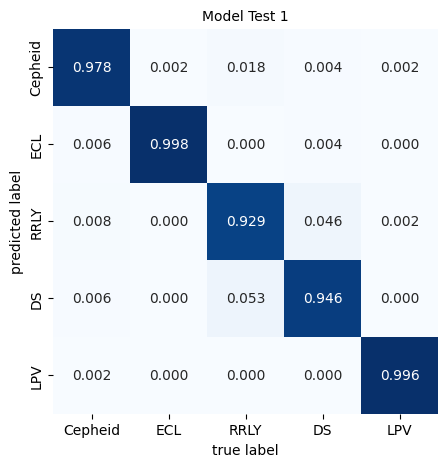

In [43]:
Y_pred_probs = model_test1.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)
plot_confusion_matrix(Y_test, Y_pred, title=f'Model Test 1', class_names=['Cepheid','ECL','RRLY','DS','LPV'], figsize=(5,5))

In [44]:
def make_model_test2(input_shape, num_classes):
    # Mahabal deep architecture with padding='same' as opposed to the default padding='valid'
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPool2D(pool_size=(2,2))(x)
    x = layers.Dropout(rate=0.1)(x)

    x = layers.Conv2D(filters=128, kernel_size=(5,5), activation='relu', padding='same')(x)
    x = layers.Conv2D(filters=256, kernel_size=(5,5), activation='relu', padding='same')(x)

    x = layers.Flatten()(x)

    x = layers.Dense(units=512)(x)
    x = layers.Dropout(rate=0.5)(x)
    x = layers.Dense(units=512)(x)

    outputs = layers.Dense(units=num_classes, activation='softmax')(x)

    return keras.Model(inputs,outputs)

In [45]:
model_test2 = make_model_test2(input_shape=X_train.shape[1:], num_classes=5)

model_test2.compile(optimizer=keras.optimizers.Adam(3e-4),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.SparseCategoricalAccuracy()])

In [46]:
history2 = model_test2.fit(X_train,Y_train,
                    batch_size=64,
                    epochs=6,
                    validation_data=(X_validate,Y_validate))

Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 153ms/step - loss: 0.2607 - sparse_categorical_accuracy: 0.9089 - val_loss: 0.1221 - val_sparse_categorical_accuracy: 0.9564
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 157ms/step - loss: 0.1111 - sparse_categorical_accuracy: 0.9620 - val_loss: 0.1019 - val_sparse_categorical_accuracy: 0.9660
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 152ms/step - loss: 0.0865 - sparse_categorical_accuracy: 0.9700 - val_loss: 0.0972 - val_sparse_categorical_accuracy: 0.9612
Epoch 4/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 153ms/step - loss: 0.0773 - sparse_categorical_accuracy: 0.9728 - val_loss: 0.0741 - val_sparse_categorical_accuracy: 0.9732
Epoch 5/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 152ms/step - loss: 0.0636 - sparse_categorical_accuracy: 0.9772 - val_loss: 0.0640 - val_sparse_categorical_accuracy: 0.9752
Epoch 6/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 154ms/step - loss: 0.0541 - sparse_categorical_accuracy: 0.9807 - val_loss: 0.0747 - val_sparse_categorical_accuracy:

In [47]:
results = model_test2.evaluate(X_test,Y_test,batch_size=128)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0712 - sparse_categorical_accuracy: 0.9764


the accuracy of 97.64% is a notable improvement to the Mahabal 2017 deep architecture

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


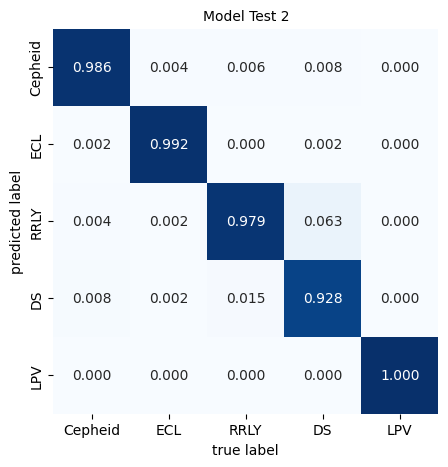

In [48]:
Y_pred_probs = model_test2.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)
plot_confusion_matrix(Y_test, Y_pred, title=f'Model Test 2', class_names=['Cepheid','ECL','RRLY','DS','LPV'], figsize=(5,5))

In [49]:
def make_model_test3(input_shape, num_classes):
    # Mahabal deep architecture with padding='same' and kernel size (3,3)
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPool2D(pool_size=(2,2))(x)
    x = layers.Dropout(rate=0.1)(x)

    x = layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = layers.Conv2D(filters=256, kernel_size=(3,3), activation='relu', padding='same')(x)

    x = layers.Flatten()(x)

    x = layers.Dense(units=512)(x)
    x = layers.Dropout(rate=0.5)(x)
    x = layers.Dense(units=512)(x)

    outputs = layers.Dense(units=num_classes, activation='softmax')(x)

    return keras.Model(inputs,outputs)

In [50]:
model_test3 = make_model_test3(input_shape=X_train.shape[1:], num_classes=5)

model_test3.compile(optimizer=keras.optimizers.Adam(3e-4),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.SparseCategoricalAccuracy()])

In [51]:
history3 = model_test3.fit(X_train,Y_train,
                    batch_size=64,
                    epochs=6,
                    validation_data=(X_validate,Y_validate))

Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 100ms/step - loss: 0.2570 - sparse_categorical_accuracy: 0.9110 - val_loss: 0.1084 - val_sparse_categorical_accuracy: 0.9616
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 100ms/step - loss: 0.1134 - sparse_categorical_accuracy: 0.9614 - val_loss: 0.1036 - val_sparse_categorical_accuracy: 0.9628
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 100ms/step - loss: 0.0881 - sparse_categorical_accuracy: 0.9693 - val_loss: 0.1042 - val_sparse_categorical_accuracy: 0.9644
Epoch 4/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 100ms/step - loss: 0.0749 - sparse_categorical_accuracy: 0.9749 - val_loss: 0.0752 - val_sparse_categorical_accuracy: 0.9736
Epoch 5/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - loss: 0.0635 - sparse_categorical_accuracy: 0.9778 - val_loss: 0.0743 - val_sparse_categorical_accuracy: 0.9764
Epoch 6/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - loss: 0.0564 - sparse_categorical_accuracy: 0.9804 - val_loss: 0.0875 - val_sparse_categorical_accuracy:

In [52]:
results = model_test3.evaluate(X_test,Y_test,batch_size=128)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0859 - sparse_categorical_accuracy: 0.9756


decrease in kernel size had a very minor negative affect on the model accuracy

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


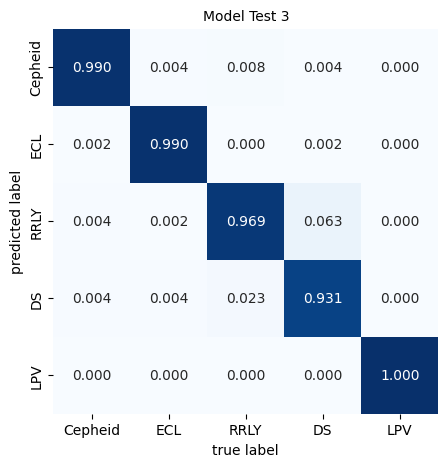

In [53]:
Y_pred_probs = model_test3.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)
plot_confusion_matrix(Y_test, Y_pred, title=f'Model Test 3', class_names=['Cepheid','ECL','RRLY','DS','LPV'], figsize=(5,5))

In [35]:
def make_model_test4(input_shape, num_classes):
    # Mahabal deep architecture with padding='same' and Dense layer activation='relu' instead of activation=None
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPool2D(pool_size=(2,2))(x)
    x = layers.Dropout(rate=0.1)(x)

    x = layers.Conv2D(filters=128, kernel_size=(5,5), activation='relu', padding='same')(x)
    x = layers.Conv2D(filters=256, kernel_size=(5,5), activation='relu', padding='same')(x)

    x = layers.Flatten()(x)

    x = layers.Dense(units=512, activation='relu')(x)
    x = layers.Dropout(rate=0.5)(x)
    x = layers.Dense(units=512, activation='relu')(x)

    outputs = layers.Dense(units=num_classes, activation='softmax')(x)

    return keras.Model(inputs,outputs)

In [36]:
model_test4 = make_model_test4(input_shape=X_train.shape[1:], num_classes=5)

model_test4.compile(optimizer=keras.optimizers.Adam(3e-4),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.SparseCategoricalAccuracy()])

In [37]:
history4 = model_test4.fit(X_train,Y_train,
                    batch_size=64,
                    epochs=6,
                    validation_data=(X_validate,Y_validate))

Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 70ms/step - loss: 0.2838 - sparse_categorical_accuracy: 0.8977 - val_loss: 0.1083 - val_sparse_categorical_accuracy: 0.9604
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 0.1255 - sparse_categorical_accuracy: 0.9557 - val_loss: 0.1098 - val_sparse_categorical_accuracy: 0.9604
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 0.1082 - sparse_categorical_accuracy: 0.9621 - val_loss: 0.0950 - val_sparse_categorical_accuracy: 0.9672
Epoch 4/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 0.0874 - sparse_categorical_accuracy: 0.9701 - val_loss: 0.0788 - val_sparse_categorical_accuracy: 0.9708
Epoch 5/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 0.0740 - sparse_categorical_accuracy: 0.9748 - val_loss: 0.0902 - val_sparse_categorical_accuracy: 0.9724
Epoch 6/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 0.0683 - sparse_categorical_accuracy: 0.9764 - val_loss: 0.0809 - val_sparse_categorical_accuracy: 0.974

In [38]:
results = model_test4.evaluate(X_test,Y_test,batch_size=128)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0781 - sparse_categorical_accuracy: 0.9784


In [ ]:
# keras.utils.plot_model(model_test4,show_shapes=True,to_file='model_test4_architecture.png')

further increase in accuracy

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


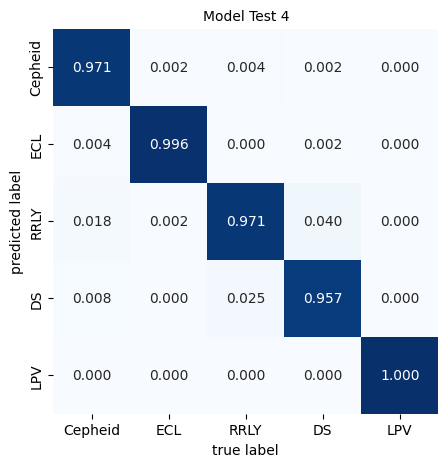

In [58]:
Y_pred_probs = model_test4.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)
plot_confusion_matrix(Y_test, Y_pred, title=f'Model Test 4', class_names=['Cepheid','ECL','RRLY','DS','LPV'], figsize=(5,5))

In [40]:
def make_model_test5(input_shape, num_classes):
    # model test 4 with fewer filters in the convolution layers
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPool2D(pool_size=(2,2))(x)
    x = layers.Dropout(rate=0.1)(x)

    x = layers.Conv2D(filters=64, kernel_size=(5,5), activation='relu', padding='same')(x)
    x = layers.Conv2D(filters=128, kernel_size=(5,5), activation='relu', padding='same')(x)

    x = layers.Flatten()(x)

    x = layers.Dense(units=512, activation='relu')(x)
    x = layers.Dropout(rate=0.5)(x)
    x = layers.Dense(units=512, activation='relu')(x)

    outputs = layers.Dense(units=num_classes, activation='softmax')(x)

    return keras.Model(inputs,outputs)

In [41]:
model_test5 = make_model_test5(input_shape=X_train.shape[1:], num_classes=5)

model_test5.compile(optimizer=keras.optimizers.Adam(3e-4),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.SparseCategoricalAccuracy()])

In [42]:
history5 = model_test5.fit(X_train,Y_train,
                    batch_size=64,
                    epochs=6,
                    validation_data=(X_validate,Y_validate))

Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 0.3421 - sparse_categorical_accuracy: 0.8730 - val_loss: 0.1602 - val_sparse_categorical_accuracy: 0.9444
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.1587 - sparse_categorical_accuracy: 0.9473 - val_loss: 0.1389 - val_sparse_categorical_accuracy: 0.9524
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.1314 - sparse_categorical_accuracy: 0.9552 - val_loss: 0.1207 - val_sparse_categorical_accuracy: 0.9576
Epoch 4/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.1210 - sparse_categorical_accuracy: 0.9598 - val_loss: 0.0927 - val_sparse_categorical_accuracy: 0.9676
Epoch 5/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.1036 - sparse_categorical_accuracy: 0.9635 - val_loss: 0.1096 - val_sparse_categorical_accuracy: 0.9664
Epoch 6/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.0985 - sparse_categorical_accuracy: 0.9666 - val_loss: 0.0914 - val_sparse_categorical_accuracy: 0.969

In [43]:
results = model_test5.evaluate(X_test,Y_test,batch_size=128)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0917 - sparse_categorical_accuracy: 0.9712


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


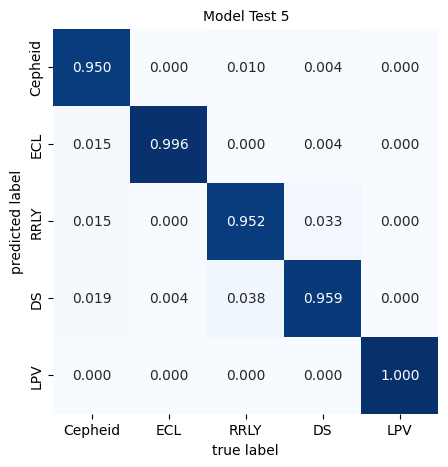

In [44]:
Y_pred_probs = model_test5.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)
plot_confusion_matrix(Y_test, Y_pred, title=f'Model Test 5', class_names=['Cepheid','ECL','RRLY','DS','LPV'], figsize=(5,5))

After some experimentation, the best model is model test 4, with a deep architecture, activation function in the dense layer, and convolution layer padding. Accuracy = 97.88%.

### Global Average Pooling in place of Flatten ###

In [46]:
def make_model_test6(input_shape, num_classes):
    # Mahabal deep architecture with padding='same' and Dense layer activation='relu' instead of activation=None
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPool2D(pool_size=(2,2))(x)
    x = layers.Dropout(rate=0.1)(x)

    x = layers.Conv2D(filters=128, kernel_size=(5,5), activation='relu', padding='same')(x)
    x = layers.Conv2D(filters=256, kernel_size=(5,5), activation='relu', padding='same')(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(units=512, activation='relu')(x)
    x = layers.Dropout(rate=0.5)(x)
    x = layers.Dense(units=512, activation='relu')(x)

    outputs = layers.Dense(units=num_classes, activation='softmax')(x)

    return keras.Model(inputs,outputs)

In [48]:
model_test6 = make_model_test6(input_shape=X_train.shape[1:], num_classes=5)

model_test6.compile(optimizer=keras.optimizers.Adam(3e-4),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.SparseCategoricalAccuracy()])

In [49]:
history6 = model_test6.fit(X_train,Y_train,
                    batch_size=64,
                    epochs=6,
                    validation_data=(X_validate,Y_validate))

Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - loss: 0.8926 - sparse_categorical_accuracy: 0.6480 - val_loss: 0.5389 - val_sparse_categorical_accuracy: 0.7936
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.4323 - sparse_categorical_accuracy: 0.8340 - val_loss: 0.3451 - val_sparse_categorical_accuracy: 0.8508
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.3293 - sparse_categorical_accuracy: 0.8776 - val_loss: 0.2425 - val_sparse_categorical_accuracy: 0.9100
Epoch 4/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.4290 - sparse_categorical_accuracy: 0.8529 - val_loss: 0.4254 - val_sparse_categorical_accuracy: 0.8512
Epoch 5/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 0.6533 - sparse_categorical_accuracy: 0.7979 - val_loss: 0.3148 - val_sparse_categorical_accuracy: 0.8808
Epoch 6/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 0.3893 - sparse_categorical_accuracy: 0.8660 - val_loss: 0.2267 - val_sparse_categorical_accuracy: 0.913

In [50]:
results = model_test6.evaluate(X_test,Y_test,batch_size=128)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2129 - sparse_categorical_accuracy: 0.9260


79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


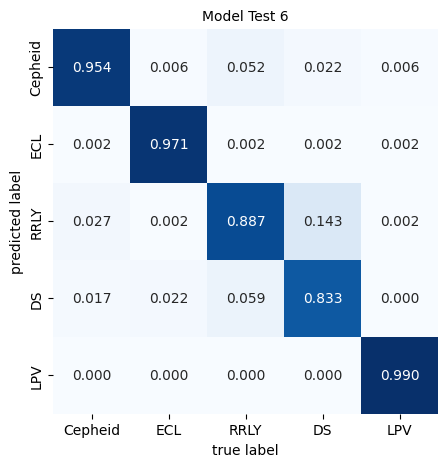

In [52]:
Y_pred_probs = model_test6.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)
plot_confusion_matrix(Y_test, Y_pred, title=f'Model Test 6', class_names=['Cepheid','ECL','RRLY','DS','LPV'], figsize=(5,5))

## Some basic data augmentation

In [ ]:
# https://keras.io/examples/vision/image_classification_from_scratch/
# specifically under "Using image data augmentation"

# keras.layers.RandomGaussianBlur(
#     factor=1.0,
#     kernel_size=3,
#     sigma=1.0,
#     value_range=(0, 255),
#     data_format=None,
#     seed=None,
#     **kwargs

In [ ]:
def data_augmentation(images):
    images = keras.layers.RandomGaussianBlur(factor=0.3)(images)
    return images

In [81]:
X_train_augmented = data_augmentation(X_train)

In [82]:
X_train_combined = np.concatenate((X_train,X_train_augmented), axis=0)

In [83]:
Y_train_augmented = Y_train.copy()
Y_train_combined = np.concatenate((Y_train, Y_train_augmented))

In [84]:
model_aug = make_model_test4(input_shape=X_train_combined.shape[1:], num_classes=5)

model_aug.compile(optimizer=keras.optimizers.Adam(3e-4),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.SparseCategoricalAccuracy()])

In [85]:
history_aug = model_aug.fit(X_train_combined,Y_train_combined,
                    batch_size=64,
                    epochs=6,
                    validation_data=(X_validate,Y_validate))

Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 68ms/step - loss: 0.2210 - sparse_categorical_accuracy: 0.9204 - val_loss: 0.0908 - val_sparse_categorical_accuracy: 0.9664
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - loss: 0.1035 - sparse_categorical_accuracy: 0.9650 - val_loss: 0.0789 - val_sparse_categorical_accuracy: 0.9732
Epoch 3/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - loss: 0.0800 - sparse_categorical_accuracy: 0.9719 - val_loss: 0.0755 - val_sparse_categorical_accuracy: 0.9748
Epoch 4/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - loss: 0.0714 - sparse_categorical_accuracy: 0.9752 - val_loss: 0.0668 - val_sparse_categorical_accuracy: 0.9760
Epoch 5/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - loss: 0.0732 - sparse_categorical_accuracy: 0.9757 - val_loss: 0.0760 - val_sparse_categorical_accuracy: 0.9752
Epoch 6/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - loss: 0.0920 - sparse_categorical_accuracy: 0.9723 - val_loss: 0.1077 - val_sparse_categorical_accuracy: 0.970

In [86]:
results = model_aug.evaluate(X_test,Y_test,batch_size=128)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1239 - sparse_categorical_accuracy: 0.9700


79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


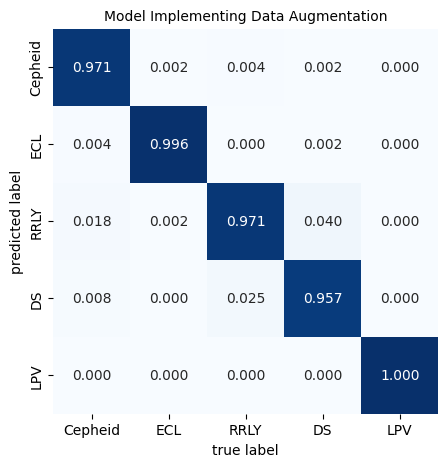

In [87]:
Y_pred_probs = model_test4.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)
plot_confusion_matrix(Y_test, Y_pred, title=f'Model Implementing Data Augmentation', class_names=['Cepheid','ECL','RRLY','DS','LPV'], figsize=(5,5))